# Análise Comparativa de Modelos

**Projeto:** Projeto ANEEL - Energia em Risco: Análise de Dados de Continuidade Elétrica e Previsão de Risco Regulatório

**Metodologia:** CRISP-DM

**Período de Análise:** 2021 – 2025

---

## Visão Geral

Este notebook consolida a **Fase 4 do CRISP-DM - Modelagem (Modeling)** com o consumo da base preparada, a definição das métricas, do modelo de baseline e dos modelos candidatos. Também serão realizados o treinamento dos modelos, o ajuste de hiperparâmetros, a análise comparativa dos modelos otimizados e, por fim, a seleção do modelo campeão. 

---

## Sumário

- **1.** Configurações do ambiente
- **2.** Objetivo da modelagem
- **3.** Carregamento da base preparada
- **4.** Métricas de avaliação
- **5.** Baseline e estratégia de avaliação
    - **5.1.** Definição do modelo baseline
    - **5.2.** Matriz de confusão baseline
- **6.** Modelos candidatos
- **7.** Treinamento e comparação inicial
- **8.** Ajuste de limiares na validação
    - **8.1.** Cenário 01: Teste com ajuste do limiar do F1-Score
    - **8.2.** Cenário 02: Teste com Recall mínimo de 60%
    - **8.3.** Cenário 02: Teste com Recall mínimo de 50%
- **9.** Ajuste temporal dos hiperparâmetros
    - **9.1.** Definição de hiperparâmetros e validação cruzada temporal
    - **9.2.** Comparativo de desempenho (pré vs. pós-tuning)
- **10.** Seleção do modelo campeão e validação final
    - **10.1.** Ajuste do limiar operacional
    - **10.2.** Avaliação final no teste
    - **10.3.** Persistência do modelo campeão
    - **10.4.** Matriz de confusão campeão
- **11**. Conclusão

---


## 1. Configurações do ambiente

In [28]:
# Importações e configurações do ambiente
import os
import sys
from pathlib import Path
import time
import json

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, SymLogNorm
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown
import joblib

from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
)

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from scipy.stats import loguniform

# Configurações de diretórios e constantes
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import PROCESSED_DIR
from src.data.constants import ANO_INICIO, ANO_FIM

MODEL_DATA_DIR = PROCESSED_DIR / "modeling"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
METADATA_DIR = PROJECT_ROOT / "docs" / "metadata"
MODEL_DIR = PROJECT_ROOT / "models"

os.makedirs(MODEL_DATA_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(METADATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

RANDOM_STATE = 42

print(f"Período analisado: {ANO_INICIO}-{ANO_FIM}")
print(f"RANDOM_STATE: {RANDOM_STATE}")

Período analisado: 2021-2025
RANDOM_STATE: 42


In [9]:
# Configurações de exibição e estilo
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", lambda value: f"{value:.8f}")

# Definindo a paleta de cores
colors = ["#959300", "#01719f", "#004e72"]
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette(colors))

custom_cmap = LinearSegmentedColormap.from_list("custom_colors", colors[::-1])
custom_cmap.set_under(colors[::-1][0])
custom_cmap.set_bad(colors[::-1][0])

In [51]:
# Configurando variáveis de ambiente para armazenamento de figuras e metadados

TABLE_BASELINE_METRICS = METADATA_DIR / "n05_baseline_metrics.csv"
TABLE_MODEL_SPECS = METADATA_DIR / "n05_model_specs.csv"
TABLE_INITIAL_TRAINING_RESULTS = METADATA_DIR / "n05_initial_training_results.csv"
TABLE_TUNING_RESULTS = METADATA_DIR / "n05_tuning_training_results.csv"
TABLE_BEST_F1_SCORE = METADATA_DIR / "n05_best_f1_score.csv"
TABLE_RECALL_50_FLOOR = METADATA_DIR / "n05_recall_50_floor.csv"
TABLE_RECALL_60_FLOOR = METADATA_DIR / "n05_recall_60_floor.csv"
TABLE_OPERATIONAL_COMPARISON = METADATA_DIR / "n05_operational_comparison.csv"
TABLE_CHAMPION_METRICS = METADATA_DIR / "n05_champion_metrics.csv"

FIGURE_BASELINE_CONFUSION_MATRIX = FIGURES_DIR / "n05_baseline_confusion_matrix.png"
FIGURE_TUNING_COMPARATIVE_ANALYSIS = FIGURES_DIR / "n05_tuning_comparative_analysis.png"
FIGURE_OPERATIONAL_THRESHOLD_COMPARISON = FIGURES_DIR / "n05_operational_threshold_comparison.png"
FIGURE_CHAMPION_CONFUSION_MATRIX = FIGURES_DIR / "n05_final_confusion_matrix.png"

MODEL_METADATA_JSON = MODEL_DATA_DIR / "model_metadata.json"
MODEL_PATH = MODEL_DIR / "model_selected.joblib"
MODEL_METADATA_PATH = MODEL_DIR / "model_metadata.joblib"


---

## 2. Objetivo da modelagem

Comparar modelos de classificação capazes de prever o `alvo`, isto é, a ocorrência de transgressão regulatória no período seguinte para cada conjunto e indicador.

1. **Entradas esperadas do notebook 04:** `X_train`, `y_train`, `X_validation`, `y_validation`, `X_test` e `y_test`.

2. **Partições:** Treino `(2021–2023)`, validação `(2024)` e teste `(2025)`. A ordem temporal deve ser preservada em todas as avaliações.

3. **Modelo Baseline:** Classificador simples e interpretável, utilizado como referência mínima.

4. **Modelos Candidatos:** Modelos lineares e baseados em bagging e boosting, treinados com tratamento do desbalanceamento e validação cruzada temporal (*TimeSeriesSplit*).

5. **Métricas Prioritárias:** `Precision`, `Recall`, `F1-score`, `ROC-AUC`, `PR-AUC` e `Matriz de Confusão`. A acurácia não será usada como critério principal devido à raridade das transgressões.

6. **Critério de Seleção:** Escolher o modelo que ofereça melhor equilíbrio entre detecção das transgressões, precisão dos alertas, estabilidade temporal e interpretabilidade operacional.

---

## 3. Carregamento da base preparada

As matrizes são carregadas a partir das matrizes (treino, teste e validação) e pesos sugeridos exportados pelo [notebook 04_data_preparation.ipynb](04_data_preparation.ipynb). O carregamento valida a existência das seis entradas esperadas, o alinhamento das colunas e a ausência de nulos nos atributos.

In [11]:
# Carregamento e validação das matrizes exportadas pelo notebook 04

required_model_files = [
    MODEL_DATA_DIR / "X_train.parquet",
    MODEL_DATA_DIR / "X_validation.parquet",
    MODEL_DATA_DIR / "X_test.parquet",
    MODEL_DATA_DIR / "y_train.parquet",
    MODEL_DATA_DIR / "y_validation.parquet",
    MODEL_DATA_DIR / "y_test.parquet",
    MODEL_DATA_DIR / "model_weights.json",
]

# Verifica se todos os arquivos necessários existem
missing_model_files = [str(path) for path in required_model_files if not path.exists()]
if missing_model_files:
    raise FileNotFoundError(
        "Matrizes ou metadados ausentes. Execute a exportação no notebook 04:\n"
        + "\n".join(missing_model_files)
    )

# Carregamento das matrizes de treino, validação e teste, bem como os metadados do modelo
X_train = pd.read_parquet(required_model_files[0])
X_validation = pd.read_parquet(required_model_files[1])
X_test = pd.read_parquet(required_model_files[2])
y_train = pd.read_parquet(required_model_files[3])["alvo"]
y_validation = pd.read_parquet(required_model_files[4])["alvo"]
y_test = pd.read_parquet(required_model_files[5])["alvo"]
modeling_metadata = pd.read_json(required_model_files[6]).iloc[0].to_dict()
scale_pos_weight = float(modeling_metadata["scale_pos_weight"])

assert list(X_train.columns) == list(X_validation.columns) == list(X_test.columns)
assert int(X_train.isna().sum().sum()) == 0
assert int(X_validation.isna().sum().sum()) == 0
assert int(X_test.isna().sum().sum()) == 0
assert int(y_train.sum()) == int(modeling_metadata["train_positives"])
assert int(len(y_train) - y_train.sum()) == int(modeling_metadata["train_negatives"])

# Resumo das dimensões das matrizes de treino, validação e teste
model_input_summary = pd.DataFrame(
    [
        {
            "particao": "treino",
            "observacoes": len(X_train),
            "atributos": X_train.shape[1],
            "transgressoes": int(y_train.sum()),
        },
        {
            "particao": "validacao",
            "observacoes": len(X_validation),
            "atributos": X_validation.shape[1],
            "transgressoes": int(y_validation.sum()),
        },
        {
            "particao": "teste",
            "observacoes": len(X_test),
            "atributos": X_test.shape[1],
            "transgressoes": int(y_test.sum()),
        },
    ]
)

display(model_input_summary)
display(Markdown(f"""#### scale_pos_weight carregado: **{scale_pos_weight:.4f}**"""))

,particao,observacoes,atributos,transgressoes
0,treino,223184,129,70
1,validacao,75072,129,14
2,teste,69026,129,6


#### scale_pos_weight carregado: **3187.3429**

---

## 4. Métricas de avaliação

A avaliação combina métricas adequadas a classes desbalanceadas, considerando tanto a capacidade de ordenação dos riscos quanto o comportamento do modelo em um limiar operacional específico:

1. **Precision (Precisão)**  

    - **O que mede:** A proporção de verdadeiras transgressões entre todas as instâncias que o modelo classificou como transgressão ($\frac{TP}{TP + FP}$).

    - **Por que é essencial?** Mede a eficiência operacional do modelo.

2. **Recall (Sensibilidade)**  

    - **O que mede:** A proporção de transgressões reais que foram identificadas com sucesso pelo modelo ($\frac{TP}{TP + FN}$).

    - **Por que é essencial?** É a métrica de proteção regulatória. Um recall baixo significa que violações de DEC/FEC ocorrerão sem aviso prévio, gerando multas, compensações financeiras aos consumidores e autuações da ANEEL.

3. **F1-Score**  

    - **O que mede:** A média harmônica entre Precision e Recall ($2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$), atribuindo peso idêntico a ambos.

    - **Por que é essencial?** Fornece um resumo único do equilíbrio entre alarmes falsos e transgressões não detectadas em um limiar de corte fixo (0,50).

4. **ROC-AUC**  

    - **O que mede:** A probabilidade de o classificador atribuir um score mais alto a um conjunto com transgressão escolhido aleatoriamente do que a um conjunto sem transgressão.

    - **Por que é essencial?** Serve como benchmark padrão da literatura técnica e avalia a separação das classes ao longo de múltiplos limiares de falso positivo.

5. **PR-AUC**  

    - **O que mede:** O desempenho agregado do modelo integrando todos os limiares de decisão possíveis exclusivamente sobre a classe positiva (minoritária).

    - **Por que é essencial?** É o critério principal para seleção e ranqueamento dos modelos. Em bases com forte desbalanceamento, reflete a capacidade discriminatória real sem ser mascarada pelo volume massivo de instâncias sem transgressão.

6. **Matriz de Confusão**  

    - **O que mede:** O mapeamento quantitativo das predições cruzadas com a realidade, dividido em Verdadeiros Negativos (TN), Falsos Positivos (FP), Falsos Negativos (FN) e Verdadeiros Positivos (TP).
    
    - **Por que é essencial?** Permite auditar os volumes brutos de erros e acertos em cada partição temporal, possibilitando traduzir diretamente o comportamento das classificações positivas e negativas.

---

## 5. Baseline e estratégia de avaliação

O baseline sempre prevê a classe majoritária observada no treino. Ele não representa um modelo operacional, mas estabelece o desempenho mínimo que os modelos candidatos precisam superar.

A avaliação será feita nos dados de validação, utilizando `Precision`, `Recall`, `F1-score`, `ROC-AUC`, `PR-AUC` e `Matriz de confusão`.

### 5.1. Definição do modelo baseline

In [ ]:
# Baseline de classe majoritária e funções de avaliação

full_table_path = TABLE_BASELINE_METRICS
relative_table_path = os.path.relpath(full_table_path)


def evaluate_classifier(model_name, y_true, predictions, scores):
    y_true = np.asarray(y_true)
    predictions = np.asarray(predictions)
    scores = np.asarray(scores)

    try:
        roc_auc = roc_auc_score(y_true, scores)
    except ValueError:
        roc_auc = np.nan

    return {
        "modelo": model_name,
        "precision": precision_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "f1_score": f1_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "roc_auc": roc_auc,
        "pr_auc": average_precision_score(y_true, scores),
    }


def compute_pr_curve(y_true, scores):
    precision_curve, recall_curve, thresholds = precision_recall_curve(
        y_true,
        scores,
    )

    f1_curve = (
        2
        * precision_curve[:-1]
        * recall_curve[:-1]
        / (precision_curve[:-1] + recall_curve[:-1] + np.finfo(float).eps)
    )

    return precision_curve, recall_curve, thresholds, f1_curve


def select_decision_threshold(
    y_true,
    scores,
    target_recall=None,
    metric="f1",
):
    precision_curve, recall_curve, thresholds, f1_curve = compute_pr_curve(
        y_true,
        scores,
    )

    if target_recall is None:
        best_index = int(np.argmax(f1_curve))
        return {
            "threshold": float(thresholds[best_index]),
            "precision": float(precision_curve[best_index]),
            "recall": float(recall_curve[best_index]),
            "f1_score": float(f1_curve[best_index]),
        }

    feasible = recall_curve[:-1] >= target_recall

    if feasible.any():
        feasible_indices = np.flatnonzero(feasible)

        if metric == "precision":
            best_index = feasible_indices[
                np.argmax(precision_curve[:-1][feasible_indices])
            ]
        else:
            best_index = feasible_indices[np.argmax(f1_curve[feasible_indices])]
    else:
        best_index = int(np.argmax(recall_curve[:-1]))

    return {
        "threshold": float(thresholds[best_index]),
        "precision": float(precision_curve[best_index]),
        "recall": float(recall_curve[best_index]),
        "f1_score": float(f1_curve[best_index]),
    }


baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train, y_train)
baseline_predictions = baseline_model.predict(X_validation)
baseline_scores = baseline_model.predict_proba(X_validation)[:, 1]

baseline_metrics = pd.DataFrame(
    [
        evaluate_classifier(
            "baseline_classe_majoritaria",
            y_validation,
            baseline_predictions,
            baseline_scores,
        )
    ]
)
baseline_confusion = confusion_matrix(y_validation, baseline_predictions)

display(baseline_metrics)

print(f"Matriz de confusão: baseline_classe_majoritaria")
display(
    pd.DataFrame(
        index=["real_0", "real_1"],
        columns=["predito_0", "predito_1"],
        data=baseline_confusion,
    )
)

baseline_metrics.to_csv(
    full_table_path,
    index=False,
)

print(f"\nTabela salva com sucesso em: {relative_table_path}")

,modelo,precision,recall,f1_score,roc_auc,pr_auc
0,baseline_classe_majoritaria,0.00000000,0.00000000,0.00000000,0.50000000,0.00018649


Matriz de confusão: baseline_classe_majoritaria


,predito_0,predito_1
real_0,75058,0
real_1,14,0



Tabela salva com sucesso em: ..\docs\metadata\n05_baseline_metrics.csv


### 5.2 Matriz de confusão baseline

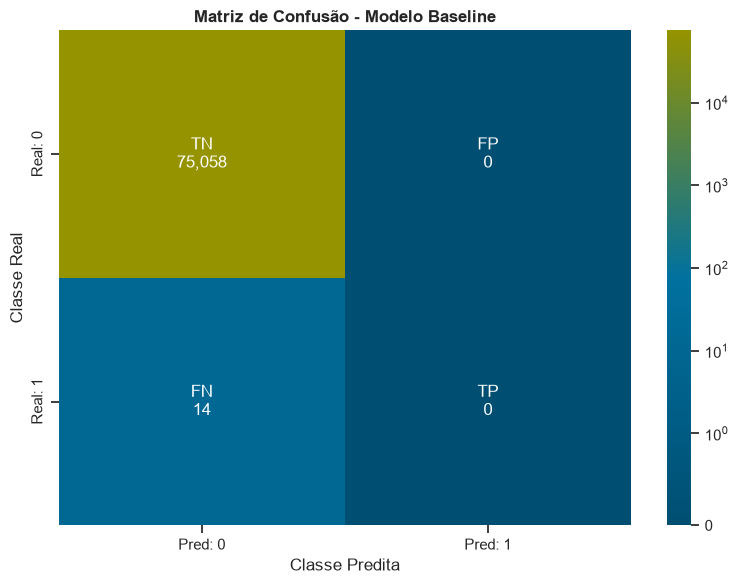


Gráfico salvo com sucesso em: ..\reports\figures\n05_baseline_confusion_matrix.png


In [ ]:
# Matriz de confusão do modelo baseline

full_image_path = FIGURE_BASELINE_CONFUSION_MATRIX
relative_image_path = os.path.relpath(full_image_path)

tn, fp, fn, tp = baseline_confusion.ravel()

labels = [
    [f"TN\n{tn:,}", f"FP\n{fp:,}"],
    [f"FN\n{fn:,}", f"TP\n{tp:,}"],
]

plt.figure(figsize=(8, 6))
sns.heatmap(
    baseline_confusion,
    annot=labels,
    fmt="",
    cmap=custom_cmap,
    norm=SymLogNorm(
        linthresh=1.0,
        vmin=0,
        vmax=baseline_confusion.max(),
        base=10,
    ),
    cbar=True,
    xticklabels=["Pred: 0", "Pred: 1"],
    yticklabels=["Real: 0", "Real: 1"],
)
plt.ylabel("Classe Real")
plt.xlabel("Classe Predita")
plt.title("Matriz de Confusão - Modelo Baseline", fontweight="bold")

plt.tight_layout()
plt.savefig(relative_image_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"\nGráfico salvo com sucesso em: {relative_image_path}")

 * O modelo classifica todas as **75.072** instâncias como pertencentes à classe negativa (`predito_0`), não gerando nenhum falso positivo (`FP = 0`), mas falhando em detectar qualquer evento de interesse (`predito_1 = 0`).
 
 * O classificador atinge **Recall de 0.00** e **Precisão de 0.00** (com **F1-Score = 0.00**), resultando em **14 falsos negativos** para as **14 ocorrências reais** da classe positiva (`real_1`).

* A métrica **ROC-AUC fica em 0.50**, caracterizando ausência de discriminação, enquanto o **PR-AUC** converge para **0.00018649** (equivalente à presença do evento raro na base: **0.0186%**).

* Apesar de apresentar uma acurácia aparente de **99.9814%** decorrente do desbalanceamento extremo, o modelo é operacionalmente nulo por não capturar nenhum verdadeiro positivo (`TP =0`).

---

## 6. Modelos candidatos

A comparação combina modelos com diferentes níveis de interpretabilidade, capacidade de capturar não linearidades e custo computacional. Foram escolhidos algoritmos de três famílias distintas: linear, bagging e boosting.


1. **Regressão logística:** 

    - **Família:** Modelo Linear.

    - **Função:** referência interpretável e base de comparação.

2. **ExtraTreesClassifier:** 

    - **Família:** Ensemble por Bagging.

    - **Função:** Capturar interações não lineares com menor variância do que árvores tradicionais.

3. **LightGBM:** 

    - **Família:** Gradient Boosting.

    - **Função:** Alta velocidade e performance em dados tabulares com classe rara.

4. **XGBoost:** 

    - **Família:** Gradient Boosting.

    - **Função:** Forte capacidade de modelagem de padrões complexos com regularização.

5. **CatBoost:** 
    
    - **Família:** Gradient Boosting (árvores simétricas).

    - **Função:** Robustez em dados tabulares e controle de viés com tratamento do desbalanceamento.

A escolha desses modelos permite comparar não apenas desempenho, mas também estabilidade operacional, custo de treinamento e capacidade de separação do evento raro.

In [ ]:
# Definição dos modelos candidatos com seus respectivos hiperparâmetros

full_table_path = TABLE_MODEL_SPECS
relative_table_path = os.path.relpath(full_table_path)

candidate_models = {
    "logistic_regression": LogisticRegression(
        solver="saga",
        l1_ratio=0.5,
        class_weight="balanced",
        max_iter=1000,
        tol=1e-2,
        random_state=RANDOM_STATE,
    ),
    "extra_trees": ExtraTreesClassifier(
        n_estimators=200,
        max_depth=12,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "lightgbm": LGBMClassifier(
        scale_pos_weight=scale_pos_weight,
        n_estimators=150,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    ),
    "xgboost": XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        n_estimators=150,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "catboost": CatBoostClassifier(
        scale_pos_weight=scale_pos_weight,
        iterations=150,
        verbose=0,
        random_state=RANDOM_STATE,
        thread_count=-1,
    ),
}


# Função para identificar o tratamento de desbalanceamento aplicado em cada modelo
def get_imbalance_treatment(model):
    params = model.get_params()
    if params.get("class_weight") is not None:
        return f"class_weight='{params['class_weight']}'"
    if params.get("scale_pos_weight") is not None:
        weight_val = params["scale_pos_weight"]
        return f"scale_pos_weight={weight_val:.4f}"
    return "Nenhum"


# DataFrame com as especificações dos modelos candidatos
model_specs = pd.DataFrame(
    [
        {
            "modelo": model_name,
            "classe": type(model).__name__,
            "tratamento_desbalanceamento": get_imbalance_treatment(model),
        }
        for model_name, model in candidate_models.items()
    ]
)

display(model_specs)

model_specs.to_csv(
    full_table_path,
    index=False,
)

print(f"\nTabela salva com sucesso em: {relative_table_path}")

,modelo,classe,tratamento_desbalanceamento
0,logistic_regression,LogisticRegression,class_weight='balanced'
1,extra_trees,ExtraTreesClassifier,class_weight='balanced_subsample'
2,lightgbm,LGBMClassifier,scale_pos_weight=3187.3429
3,xgboost,XGBClassifier,scale_pos_weight=3187.3429
4,catboost,CatBoostClassifier,scale_pos_weight=3187.3429



Tabela salva com sucesso em: ..\docs\metadata\n05_model_specs.csv


---

## 7. Treinamento e comparação inicial

Os modelos candidatos foram treinados somente com `X_train` e `y_train`. Os modelos de boosting receberam o `scale_pos_weight` calculado no [04_data_preparation.ipynb](04_data_preparation.ipynb), enquanto os modelos do scikit-learn utilizaram `class_weight` quando disponível para uso.

A comparação inicial foi feita na validação para observar o comportamento dos modelos em um cenário realista de desbalanceamento, sem alteração do limiar de classificação. O foco desta etapa foi verificar a ordenação de risco e a separação do evento raro antes do ajuste operacional.


In [ ]:
# Treinamento, inferência e avaliação dos modelos candidatos

full_table_path = TABLE_INITIAL_TRAINING_RESULTS
relative_table_path = os.path.relpath(full_table_path)

trained_models = {}
validation_predictions = {}
validation_scores = {}
validation_metrics = []

for model_name, model in candidate_models.items():
    print(f"Treinando: {model_name}")

    # 1. Treinamento (fit)
    t0_fit = time.perf_counter()
    model.fit(X_train, y_train)
    tempo_treino_s = time.perf_counter() - t0_fit

    # 2. Inferências (predict)
    t0_infer = time.perf_counter()
    predictions = model.predict(X_validation)
    scores = model.predict_proba(X_validation)[:, 1]
    tempo_pred_s = time.perf_counter() - t0_infer

    # 3. Armazenamento dos resultados
    trained_models[model_name] = model
    validation_predictions[model_name] = predictions
    validation_scores[model_name] = scores

    metrics_dict = evaluate_classifier(model_name, y_validation, predictions, scores)
    metrics_dict["tempo_treino_s"] = round(tempo_treino_s, 2)
    metrics_dict["tempo_pred_s"] = round(tempo_pred_s, 2)

    validation_metrics.append(metrics_dict)
    print(f"-> Concluído em {tempo_treino_s:.1f}s")

# 4. Consolidação dos resultados ordenada pelo PR-AUC
validation_metrics = pd.DataFrame(validation_metrics).sort_values(
    "pr_auc",
    ascending=False,
)
display(validation_metrics)

validation_metrics.to_csv(
    full_table_path,
    index=False,
)

print(f"\nTabela salva com sucesso em: {relative_table_path}")

Treinando: logistic_regression


-> Concluído em 88.8s
Treinando: extra_trees
-> Concluído em 14.3s
Treinando: lightgbm
-> Concluído em 2.4s
Treinando: xgboost
-> Concluído em 28.8s
Treinando: catboost
-> Concluído em 14.3s


,modelo,precision,recall,f1_score,roc_auc,pr_auc,tempo_treino_s,tempo_pred_s
3,xgboost,0.00000000,0.00000000,0.00000000,0.79466641,0.00173896,28.79000000,1.03000000
0,logistic_regression,0.00085646,0.35714286,0.00170882,0.60066215,0.00104418,88.79000000,0.14000000
1,extra_trees,0.00168919,0.14285714,0.00333890,0.73887146,0.00077345,14.28000000,0.76000000
2,lightgbm,0.00113766,0.28571429,0.00226629,0.61946190,0.00045825,2.42000000,0.15000000
4,catboost,0.00000000,0.00000000,0.00000000,0.58732009,0.00042198,14.30000000,0.43000000



Tabela salva com sucesso em: ..\docs\metadata\n05_initial_training_results.csv


In [16]:
# Análise comparativa dos modelos candidatos
initial_csv_path = str(TABLE_INITIAL_TRAINING_RESULTS)

df_initial = pd.read_csv(initial_csv_path).set_index("modelo")

xgb = df_initial.loc["xgboost"]
cat = df_initial.loc["catboost"]

top_model = df_initial.sort_values("pr_auc", ascending=False).iloc[0]
faster_model = df_initial.sort_values("tempo_treino_s").iloc[0]
slower_model = df_initial.sort_values("tempo_treino_s", ascending=False).iloc[0]
worst_pred = df_initial.sort_values("tempo_pred_s", ascending=False).iloc[0]

speed_factor = slower_model["tempo_treino_s"] / max(
    faster_model["tempo_treino_s"], 1e-4
)

display(
    Markdown(
        f"* Tanto o **XGBoost** quanto o **CatBoost** registraram Precisão, Recall e F1-Score nulos, "
        f" demonstrando que o limiar de decisão padrão `(0.5)` não é adequado para esses modelos.\n\n"
        f"* Apesar do F1-Score nulo no limiar padrão, o **{top_model.name}** "
        f"atingiu os maiores valores de **ROC-AUC ({top_model['roc_auc']:.4f})** e **PR-AUC ({top_model['pr_auc']:.6f})** provando ter a"
        f"melhor capacidade de ordenação de risco entre todos os concorrentes.\n\n"
        f"* O ROC-AUC apresentou patamares otimistas entre **{df_initial['roc_auc'].min():.3f} e {df_initial['roc_auc'].max():.3f}** "
        f"devido ao volume de verdadeiros negativos, enquanto o PR-AUC variou entre **{df_initial['pr_auc'].min():.6f} e "
        f"{df_initial['pr_auc'].max():.6f}**, "
        f"refletindo a real severidade do evento raro.\n\n"
        f"* O **{faster_model.name}** destacou-se pela velocidade de treino (**{faster_model['tempo_treino_s']:.2f} s**), "
        f"sendo cerca de **{speed_factor:.1f}x mais veloz** que o mais lento (**{slower_model.name}**, com "
        f"**{slower_model['tempo_treino_s']:.2f} s**), "
        f"enquanto o **{worst_pred.name}** registrou o maior tempo de predição (**{worst_pred['tempo_pred_s']:.2f} s**)."
    )
)

* Tanto o **XGBoost** quanto o **CatBoost** registraram Precisão, Recall e F1-Score nulos,  demonstrando que o limiar de decisão padrão `(0.5)` não é adequado para esses modelos.

* Apesar do F1-Score nulo no limiar padrão, o **xgboost** atingiu os maiores valores de **ROC-AUC (0.7947)** e **PR-AUC (0.001739)** provando ter amelhor capacidade de ordenação de risco entre todos os concorrentes.

* O ROC-AUC apresentou patamares otimistas entre **0.587 e 0.795** devido ao volume de verdadeiros negativos, enquanto o PR-AUC variou entre **0.000422 e 0.001739**, refletindo a real severidade do evento raro.

* O **lightgbm** destacou-se pela velocidade de treino (**2.42 s**), sendo cerca de **36.7x mais veloz** que o mais lento (**logistic_regression**, com **88.79 s**), enquanto o **xgboost** registrou o maior tempo de predição (**1.03 s**).

---

## 8. Análise de limiares na validação

O limiar de corte padrão `0,50` é conceitualmente inadequado para classes raras, pois tende a suprimir a classe minoritária. Esta etapa explora a curva Precision-Recall (PR-AUC) no conjunto de validação para identificar pontos de operação adequados para diferentes critérios de negócio.


A análise foi conduzida em três cenários:  
1. maximização do F1-Score;  
2. exigência mínima de Recall de 60%;  
3. exigência mínima de Recall de 50%.

Esse procedimento respeita a regra de evitar vazamento de dados: o conjunto de teste foi mantido reservado para a avaliação final.

### 8.1. Cenário 01: maximização do F1-Score

Neste primeiro cenário, busca-se o limiar de decisão que maximiza o $F_1\text{-score}$, que calcula a média harmônica tradicional entre Precisão e Recall. O objetivo é encontrar o ponto ótimo que equilibre matematicamente a capacidade de capturar transgressões com a redução de falsos positivos, assumindo pesos estritamente equivalentes para ambos os tipos de erro.

In [ ]:
# PR-AUC com precisão completa e melhor limiar de F1 na validação

full_table_path = TABLE_BEST_F1_SCORE
relative_table_path = os.path.relpath(full_table_path)

threshold_rows = []

for model_name, scores in validation_scores.items():
    threshold_info = select_decision_threshold(
        y_validation,
        scores,
    )

    threshold_rows.append(
        {
            "modelo": model_name,
            "pr_auc": average_precision_score(y_validation, scores),
            "melhor_limiar_f1": threshold_info["threshold"],
            "melhor_precision": threshold_info["precision"],
            "melhor_recall": threshold_info["recall"],
            "melhor_f1": threshold_info["f1_score"],
            "acertos_positivos": int(
                round(threshold_info["recall"] * y_validation.sum())
            ),
        }
    )

threshold_analysis = pd.DataFrame(threshold_rows).sort_values(
    "pr_auc",
    ascending=False,
)

display(
    threshold_analysis.style.format(
        {
            "pr_auc": "{:.8f}",
            "melhor_limiar_f1": "{:.8f}",
            "melhor_precision": "{:.8f}",
            "melhor_recall": "{:.8f}",
            "melhor_f1": "{:.8f}",
        }
    )
)

threshold_analysis.to_csv(
    full_table_path,
    index=False,
)

print(f"\nTabela salva com sucesso em: {relative_table_path}")

,modelo,pr_auc,melhor_limiar_f1,melhor_precision,melhor_recall,melhor_f1,acertos_positivos
3,xgboost,0.00173896,0.00658884,0.00877193,0.07142857,0.01562500,1
0,logistic_regression,0.00104418,0.60864651,0.00602410,0.07142857,0.01111111,1
1,extra_trees,0.00077345,0.74020496,0.00371747,0.07142857,0.00706714,1
2,lightgbm,0.00045825,1.00000000,0.00113766,0.28571429,0.00226629,4
4,catboost,0.00042198,0.01285467,0.00280899,0.07142857,0.00540541,1



Tabela salva com sucesso em: ..\docs\metadata\n05_best_f1_score.csv


* Verifica-se uma penalização severa do Recall pelo equilíbrio harmônico. Como o F1-Score atribui peso igual à Precisão e ao Recall, a função de otimização priorizou evitar falsos positivos a qualquer custo. O resultado foi um Recall crítico de apenas **7,14%** na maioria dos modelos, detectando apenas **1 caso positivo** no período.

* Os modelos lineares e baseados em *bagging* exigiram limiares elevados (`0,6086` na Regressão Logística e `0,7402` no Extra Trees), enquanto os modelos de *gradient boosting* operaram em patamares muito inferiores (`0,0066` no XGBoost e `0,0129` no CatBoost).

* O XGBoost apresentou o melhor equilíbrio de F1-Score (`0,0156`) e a maior área sob a curva (`PR-AUC` de `0,001739`), demonstrando maior estabilidade para separar o ruído na cauda da distribuição em comparação aos demais concorrentes.

* O LightGBM teve o melhor F1-score com um limiar de `1,00000000`. Embora tenha obtido o maior Recall (`28,57%`), o modelo gerou um número elevado de falsos positivos, gerando a menor precisão (`~0,0011`) entre os algoritmos testados.

### 8.2. Cenário 02: Recall mínimo de 60%

Neste segundo cenário, inverte-se a prioridade em favor da segurança regulatória: o modelo tem uma restrição para capturar no mínimo 60% das transgressões reais na validação, buscando o limiar mais alto possível que satisfaça essa condição. O objetivo operacional é reduzir drasticamente os falsos negativos (transgressões não identificadas pela fiscalização), aceitando conscientemente o custo operacional de inspecionar mais falsos positivos.

In [ ]:
# Análise de limiar com Recall mínimo de 60%

full_table_path = TABLE_RECALL_60_FLOOR
relative_table_path = os.path.relpath(full_table_path)

minimum_recall = 0.60
minimum_positive_hits = int(np.ceil(minimum_recall * y_validation.sum()))
recall_constrained_rows = []

for model_name, scores in validation_scores.items():
    threshold_info = select_decision_threshold(
        y_validation,
        scores,
        target_recall=minimum_recall,
        metric="precision",
    )

    recall_constrained_rows.append(
        {
            "modelo": model_name,
            "pr_auc": average_precision_score(y_validation, scores),
            "limiar_recall_minimo": threshold_info["threshold"],
            "precision": threshold_info["precision"],
            "recall": threshold_info["recall"],
            "f1_score": threshold_info["f1_score"],
            "acertos_positivos": int(
                round(threshold_info["recall"] * y_validation.sum())
            ),
            "status_recall": (
                "atingido"
                if threshold_info["recall"] >= minimum_recall
                else "não atingido"
            ),
        }
    )

recall_constrained_analysis = pd.DataFrame(recall_constrained_rows).sort_values(
    ["status_recall", "precision"],
    ascending=[True, False],
)

print(f"Recall mínimo solicitado: {minimum_recall:.0%}")
print(
    f"Acertos positivos mínimos necessários: {minimum_positive_hits} de {int(y_validation.sum())}"
)
display(
    recall_constrained_analysis.style.format(
        {
            "pr_auc": "{:.8f}",
            "limiar_recall_minimo": "{:.8f}",
            "precision": "{:.8f}",
            "recall": "{:.8f}",
            "f1_score": "{:.8f}",
        }
    )
)

recall_constrained_analysis.to_csv(
    full_table_path,
    index=False,
)

print(f"\nTabela salva com sucesso em: {relative_table_path}")

Recall mínimo solicitado: 60%
Acertos positivos mínimos necessários: 9 de 14


,modelo,pr_auc,limiar_recall_minimo,precision,recall,f1_score,acertos_positivos,status_recall
3,xgboost,0.00173896,0.00000251,0.00076289,0.71428571,0.00152416,10,atingido
1,extra_trees,0.00077345,0.21415017,0.00040326,0.71428571,0.00080606,10,atingido
0,logistic_regression,0.00104418,0.48066355,0.00039015,0.64285714,0.00077983,9,atingido
4,catboost,0.00042198,0.00000000,0.00029453,0.92857143,0.00058887,13,atingido
2,lightgbm,0.00045825,0.00000000,0.00018649,1.00000000,0.00037291,14,atingido



Tabela salva com sucesso em: ..\docs\metadata\n05_recall_60_floor.csv


* Todos os cinco algoritmos obtiveram o status "atingido", elevando a detecção que antes era de apenas 1 caso (`7,14%`) no Cenário 01 para um patamar entre **9 e 14 acertos positivos** de um universo de **14 transgressões**.

* O XGBoost apresentou o melhor equilíbrio entre Recall e Precisão dentro da restrição de Recall mínimo de 60%. Mesmo assim, ele gerou muitos falsos positivos: uma Precisão de `0,0763%` significa aproximadamente **1 transgressão correta** para cada **1.300 alertas**.

* O LightGBM atingiu Recall de `100%`, mas com limiar `0`, o que equivale praticamente a classificar toda a base como positiva. Por isso, a Precisão ficou tão baixa. O CatBoost teve comportamento semelhante, embora tenha deixado passar **1 transgressão**.

* Portanto, a restrição de **Recall >= 60%** é atingível, mas revela um trade-off operacional severo. O próximo passo deve ser avaliar se esse volume de falsos positivos é aceitável ou testar uma restrição mais equilibrada.

### 8.3. Cenário 03: Recall mínimo de 50%

Neste terceiro cenário, ajusta-se a exigência operacional para um piso de cobertura mais brando: garantir que ao menos metade das transgressões regulatórias (mínimo de 7 em 14 casos) seja detectada pelo modelo. O objetivo é investigar se reduzir a restrição de Recall de 60% para 50% permite recuperar parte da precisão perdida e elevar os limiares de decisão para níveis operacionais menos saturados de falsos positivos.   

In [ ]:
# Análise de limiar com Recall mínimo de 50%

full_table_path = TABLE_RECALL_50_FLOOR
relative_table_path = os.path.relpath(full_table_path)

minimum_recall = 0.50
minimum_positive_hits = int(np.ceil(minimum_recall * y_validation.sum()))
recall_constrained_rows = []

for model_name, scores in validation_scores.items():
    threshold_info = select_decision_threshold(
        y_validation,
        scores,
        target_recall=minimum_recall,
        metric="precision",
    )

    recall_constrained_rows.append(
        {
            "modelo": model_name,
            "pr_auc": average_precision_score(y_validation, scores),
            "limiar_recall_minimo": threshold_info["threshold"],
            "precision": threshold_info["precision"],
            "recall": threshold_info["recall"],
            "f1_score": threshold_info["f1_score"],
            "acertos_positivos": int(
                round(threshold_info["recall"] * y_validation.sum())
            ),
            "status_recall": (
                "atingido"
                if threshold_info["recall"] >= minimum_recall
                else "não atingido"
            ),
        }
    )

recall_50_constrained_analysis = pd.DataFrame(recall_constrained_rows).sort_values(
    ["status_recall", "precision"],
    ascending=[True, False],
)

print(f"Recall mínimo solicitado: {minimum_recall:.0%}")
print(
    f"Acertos positivos mínimos necessários: {minimum_positive_hits} de {int(y_validation.sum())}"
)
display(
    recall_constrained_analysis.style.format(
        {
            "pr_auc": "{:.8f}",
            "limiar_recall_minimo": "{:.8f}",
            "precision": "{:.8f}",
            "recall": "{:.8f}",
            "f1_score": "{:.8f}",
        }
    )
)

recall_constrained_analysis.to_csv(
    full_table_path,
    index=False,
)

print(f"\nTabela salva com sucesso em: {relative_table_path}")

Recall mínimo solicitado: 50%
Acertos positivos mínimos necessários: 7 de 14


,modelo,pr_auc,limiar_recall_minimo,precision,recall,f1_score,acertos_positivos,status_recall
3,xgboost,0.00173896,0.00000251,0.00076289,0.71428571,0.00152416,10,atingido
1,extra_trees,0.00077345,0.21415017,0.00040326,0.71428571,0.00080606,10,atingido
0,logistic_regression,0.00104418,0.48066355,0.00039015,0.64285714,0.00077983,9,atingido
4,catboost,0.00042198,0.00000000,0.00029453,0.92857143,0.00058887,13,atingido
2,lightgbm,0.00045825,0.00000000,0.00018649,1.00000000,0.00037291,14,atingido



Tabela salva com sucesso em: ..\docs\metadata\n05_recall_50_floor.csv


- O XGBoost continua sendo o mais equilibrado entre Precisão e Recall nessa restrição.

- A Regressão Logística e o Extra Trees atingem exatamente `50% de Recall` (**7 acertos**), com limiares mais altos e seguros (`0,4881` e `0,2542`, respectivamente), o que resultou em um ganho direto de precisão em relação ao cenário de 60%.

- Para XGBoost, CatBoost e LightGBM, a transição para a meta de 50% não alterou em nada os pontos de corte nem as métricas em comparação ao cenário anterior.

- Mesmo com a restrição menor, a Precisão continua muito baixa. Isso mostra que o problema não é apenas escolher o limiar, pois os modelos ainda não conseguem separar claramente os eventos positivos dos negativos. Além disso, a validação com apenas 14 transgressões torna as métricas bastante instáveis.

---

## 9. Ajuste temporal dos hiperparâmetros

O ajuste foi realizado apenas dentro do treino, usando `TimeSeriesSplit`. A validação de 2024 foi reservada para seleção do limiar operacional, e o teste de 2025 foi usado apenas uma vez para a avaliação final.

A otimização foi guiada por **PR-AUC**, que é a métrica mais adequada para dados fortemente desbalanceados. A ideia foi melhorar a capacidade de separação da classe positiva sem comprometer a generalização temporal do modelo.


### 9.1. Definição de hiperparâmetros e validação cruzada temporal

In [ ]:
# Definição de hiperparâmetros para RandomizedSearchCV e TimeSeriesSplit

# Vetor 1D para o target
y_train_vec = y_train.squeeze() if hasattr(y_train, "squeeze") else y_train

# Definição dos estimadores
selected_candidates = {
    "logistic_regression": Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    solver="lbfgs",
                    class_weight="balanced",
                    tol=1e-2,
                    max_iter=2000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),
    "extra_trees": ExtraTreesClassifier(
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "lightgbm": LGBMClassifier(
        scale_pos_weight=scale_pos_weight,
        verbosity=-1,
        random_state=RANDOM_STATE,
        n_jobs=2,
    ),
    "xgboost": XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric="aucpr",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=2,
    ),
    "catboost": CatBoostClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric="PRAUC",
        verbose=0,
        allow_writing_files=False,
        random_state=RANDOM_STATE,
        thread_count=2,
    ),
}

# Ajuste de hiperparâmetros
parameter_distributions = {
    "logistic_regression": {
        "clf__C": loguniform(1e-4, 1.0),
    },
    "extra_trees": {
        "n_estimators": [100, 200, 300],
        "max_depth": [8, 12, 16],
        "min_samples_split": [5, 10, 20],
        "min_samples_leaf": [2, 5, 10],
        "max_features": ["sqrt", "log2", 0.5],
    },
    "xgboost": {
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.03, 0.05, 0.1],
        "subsample": [0.7, 0.9, 1.0],
        "colsample_bytree": [0.7, 0.9, 1.0],
    },
    "lightgbm": {
        "n_estimators": [100, 200, 300],
        "num_leaves": [15, 31, 63],
        "learning_rate": [0.03, 0.05, 0.1],
        "min_child_samples": [20, 50, 100],
    },
    "catboost": {
        "iterations": [150, 250, 350],
        "depth": [4, 6, 8],
        "learning_rate": [0.03, 0.05, 0.1],
        "l2_leaf_reg": [1, 3, 5, 10],
    },
}

# Métricas calculadas durante o TimeSeriesSplit
scoring_metrics = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
}

In [ ]:
# Treinamento e otimização de hiperparâmetros com TimeSeriesSplit e RandomizedSearchCV

full_table_path = TABLE_TUNING_RESULTS
relative_table_path = os.path.relpath(full_table_path)

# Divisão temporal com janela expansiva
time_split = TimeSeriesSplit(n_splits=3)
tuned_models = {}
tuning_summary = []
validation_scores_tuned = {}

for model_name, model in selected_candidates.items():
    print(f"Otimizando hiperparâmetros via TimeSeriesSplit: {model_name}...")

    t0_tune = time.perf_counter()

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=parameter_distributions[model_name],
        n_iter=5,
        scoring=scoring_metrics,
        cv=time_split,
        random_state=RANDOM_STATE,
        n_jobs=2,
        refit="pr_auc",
        error_score=np.nan,
    )

    search.fit(X_train, y_train_vec)
    tuning_time_s = time.perf_counter() - t0_tune

    best_idx = search.best_index_
    res = search.cv_results_

    tuned_models[model_name] = search.best_estimator_
    tuning_summary.append(
        {
            "modelo": model_name,
            "melhor_pr_auc_cv": res["mean_test_pr_auc"][best_idx],
            "roc_auc_cv": res["mean_test_roc_auc"][best_idx],
            "melhores_parametros": search.best_params_,
            "tempo_tuning_s": round(tuning_time_s, 2),
        }
    )
    print(
        f"-> Concluído em {tuning_time_s:.2f}s | Melhor PR-AUC médio no CV: {res['mean_test_pr_auc'][best_idx]:.8f}"
    )

tuning_summary = (
    pd.DataFrame(tuning_summary)
    .dropna(subset=["melhor_pr_auc_cv"])
    .sort_values("melhor_pr_auc_cv", ascending=False)
)

display(
    tuning_summary.style.format(
        {
            "melhor_pr_auc_cv": "{:.8f}",
            "roc_auc_cv": "{:.8f}",
            "tempo_tuning_s": "{:.2f} s",
        }
    )
)

tuning_summary.to_csv(
    full_table_path,
    index=False,
)

print(f"\nTabela salva com sucesso em: {relative_table_path}")

Otimizando hiperparâmetros via TimeSeriesSplit: logistic_regression...
-> Concluído em 37.72s | Melhor PR-AUC médio no CV: 0.00629618
Otimizando hiperparâmetros via TimeSeriesSplit: extra_trees...
-> Concluído em 166.58s | Melhor PR-AUC médio no CV: 0.00294757
Otimizando hiperparâmetros via TimeSeriesSplit: lightgbm...
-> Concluído em 30.89s | Melhor PR-AUC médio no CV: 0.01601176
Otimizando hiperparâmetros via TimeSeriesSplit: xgboost...
-> Concluído em 285.99s | Melhor PR-AUC médio no CV: 0.03072865
Otimizando hiperparâmetros via TimeSeriesSplit: catboost...
-> Concluído em 164.17s | Melhor PR-AUC médio no CV: 0.00219453


,modelo,melhor_pr_auc_cv,roc_auc_cv,melhores_parametros,tempo_tuning_s
3,xgboost,0.03072865,0.60445009,"{'subsample': 0.9, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}",285.99 s
2,lightgbm,0.01601176,0.47806023,"{'num_leaves': 31, 'n_estimators': 200, 'min_child_samples': 20, 'learning_rate': 0.05}",30.89 s
0,logistic_regression,0.00629618,0.76444341,{'clf__C': np.float64(0.00042079886696066364)},37.72 s
1,extra_trees,0.00294757,0.54042696,"{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 0.5, 'max_depth': 16}",166.58 s
4,catboost,0.00219453,0.65682931,"{'learning_rate': 0.05, 'l2_leaf_reg': 10, 'iterations': 150, 'depth': 4}",164.17 s



Tabela salva com sucesso em: ..\docs\metadata\n05_tuning_training_results.csv


### 9.2. Comparativo de desempenho (pré vs. pós-tuning)


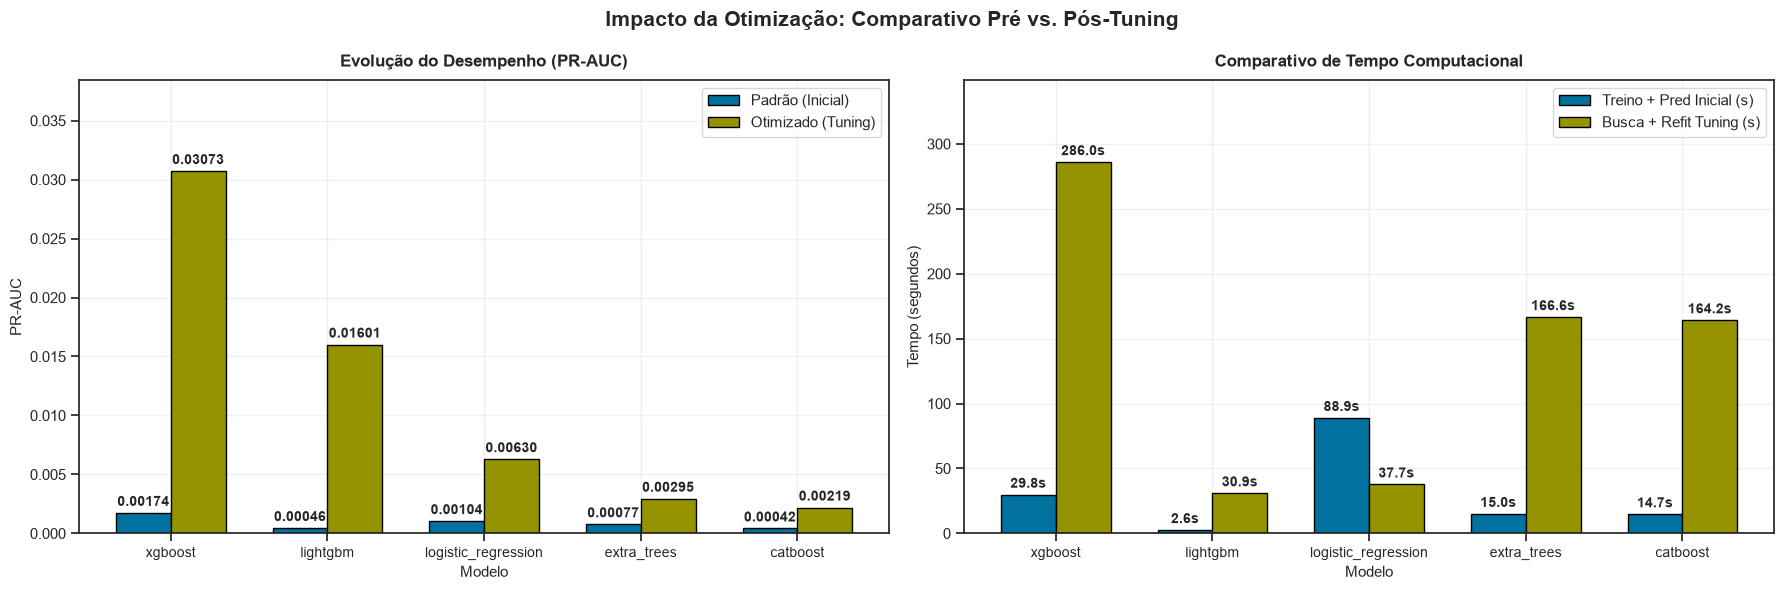


Gráfico salvo com sucesso em: ..\reports\figures\n05_tuning_comparative_analysis.png


In [ ]:
# Gráfico comparativo de desempenho e tempo de execução entre modelos pré e pós-tuning

full_image_path = FIGURE_TUNING_COMPARATIVE_ANALYSIS
relative_image_path = os.path.relpath(full_image_path)

df_initial_training = validation_metrics.sort_values(
    "pr_auc",
    ascending=False,
).reset_index(drop=True)

df_prauc_tuned = tuning_summary.sort_values(
    "melhor_pr_auc_cv", ascending=False
).reset_index(drop=True)

df_pr_auc_initial = df_initial_training.copy()
df_pr_auc_initial["tempo_inicial_total_s"] = (
    df_pr_auc_initial["tempo_treino_s"] + df_pr_auc_initial["tempo_pred_s"]
)

data_comp = pd.merge(
    df_pr_auc_initial[["modelo", "pr_auc", "tempo_inicial_total_s"]].rename(
        columns={
            "pr_auc": "pr_auc_inicial",
            "tempo_inicial_total_s": "tempo_inicial_s",
        }
    ),
    tuning_summary[["modelo", "melhor_pr_auc_cv", "tempo_tuning_s"]].rename(
        columns={
            "melhor_pr_auc_cv": "pr_auc_tuned",
        }
    ),
    on="modelo",
)

data_comp = data_comp.sort_values("pr_auc_tuned", ascending=False).reset_index(
    drop=True
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(
    "Impacto da Otimização: Comparativo Pré vs. Pós-Tuning",
    fontsize=15,
    fontweight="bold",
    y=0.98,
)

x = np.arange(len(data_comp["modelo"]))
bar_width = 0.35

rects1_auc = axes[0].bar(
    x - bar_width / 2,
    data_comp["pr_auc_inicial"],
    bar_width,
    label="Padrão (Inicial)",
    color=colors[1],
    edgecolor="black",
)
rects2_auc = axes[0].bar(
    x + bar_width / 2,
    data_comp["pr_auc_tuned"],
    bar_width,
    label="Otimizado (Tuning)",
    color=colors[0],
    edgecolor="black",
)

axes[0].set_ylabel("PR-AUC", fontsize=11)
axes[0].set_xlabel("Modelo", fontsize=11)
axes[0].set_title(
    "Evolução do Desempenho (PR-AUC)", fontweight="bold", fontsize=12, pad=10
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(data_comp["modelo"], rotation=0, fontsize=10)
axes[0].set_ylim(0, data_comp["pr_auc_tuned"].max() * 1.25)
axes[0].legend(loc="upper right", frameon=True)
axes[0].grid(True, alpha=0.3)

for i, row in data_comp.iterrows():
    axes[0].annotate(
        f"{row['pr_auc_inicial']:.5f}",
        (x[i] - bar_width / 2, row["pr_auc_inicial"]),
        textcoords="offset points",
        xytext=(0, 5),
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

for i, row in data_comp.iterrows():
    axes[0].annotate(
        f"{row['pr_auc_tuned']:.5f}",
        (x[i] + bar_width / 2, row["pr_auc_tuned"]),
        textcoords="offset points",
        xytext=(0, 5),
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

rects1_time = axes[1].bar(
    x - bar_width / 2,
    data_comp["tempo_inicial_s"],
    bar_width,
    label="Treino + Pred Inicial (s)",
    color=colors[1],
    edgecolor="black",
)
rects2_time = axes[1].bar(
    x + bar_width / 2,
    data_comp["tempo_tuning_s"],
    bar_width,
    label="Busca + Refit Tuning (s)",
    color=colors[0],
    edgecolor="black",
)

axes[1].set_ylabel("Tempo (segundos)", fontsize=11)
axes[1].set_xlabel("Modelo", fontsize=11)
axes[1].set_title(
    "Comparativo de Tempo Computacional",
    fontweight="bold",
    fontsize=12,
    pad=10,
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(data_comp["modelo"], rotation=0, fontsize=10)
axes[1].set_ylim(0, data_comp["tempo_tuning_s"].max() * 1.22)
axes[1].legend(loc="upper right", frameon=True)
axes[1].grid(True, alpha=0.3)

for i, row in data_comp.iterrows():
    axes[1].annotate(
        f"{row['tempo_inicial_s']:.1f}s",
        (x[i] - bar_width / 2, row["tempo_inicial_s"]),
        textcoords="offset points",
        xytext=(0, 5),
        ha="center",
        fontsize=10,
        fontweight="bold",
    )
    axes[1].annotate(
        f"{row['tempo_tuning_s']:.1f}s",
        (x[i] + bar_width / 2, row["tempo_tuning_s"]),
        textcoords="offset points",
        xytext=(0, 5),
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig(relative_image_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"\nGráfico salvo com sucesso em: {relative_image_path}")

In [22]:
initial_csv_path = str(TABLE_INITIAL_TRAINING_RESULTS)
tuning_csv_path = str(TABLE_TUNING_RESULTS)

df_initial = pd.read_csv(initial_csv_path).set_index("modelo")
df_tuning = pd.read_csv(tuning_csv_path).set_index("modelo")

col_pr = "melhor_pr_auc_cv" if "melhor_pr_auc_cv" in df_tuning.columns else "pr_auc_cv"

# 3. Extração dos modelos e métricas
xgb = df_tuning.loc["xgboost"]
lgb = df_tuning.loc["lightgbm"]
lr = df_tuning.loc["logistic_regression"]
et = df_tuning.loc["extra_trees"]
cb = df_tuning.loc["catboost"]

# Ganhos comparativos em relação ao modelo inicial do Tópico 7
ganho_xgb = xgb[col_pr] / max(df_initial.loc["xgboost", "pr_auc"], 1e-8)
ganho_lgb = lgb[col_pr] / max(df_initial.loc["lightgbm", "pr_auc"], 1e-8)

# Piso aleatório baseado na prevalência natural
piso_aleatorio = float(df_initial["pr_auc"].min())
multiplicador_lr = lr[col_pr] / max(piso_aleatorio, 1e-8)

# 4. Exibição dinâmica em Markdown
display(
    Markdown(
        f"* No processo de validação cruzada temporal, o **XGBoost** atingiu o maior valor na predição de transgressões regulatórias, "
        f"com PR-AUC de `{xgb[col_pr]:.8f}`, representando um ganho de cerca de `{ganho_xgb:.0f} vezes` superior ao resultado inicial, "
        f"antes da otimização de hiperparâmetros. A combinação ótima encontrada equilibra a captura de interações não-lineares complexas "
        f"com o controle da variância temporal, apesar de exigir o maior tempo total de execução (**{xgb['tempo_tuning_s']:.2f}s**).\n\n"
        f"* O **LightGBM** garantiu o segundo lugar com `PR-AUC` de `{lgb[col_pr]:.8f}`, um aumento de cerca de **{ganho_lgb:.0f} vezes** "
        f"relativo ao modelo inicial não ajustado, configurando o estimador mais eficiente de todo o conjunto ao concluir todo o processo "
        f"de tuning em apenas **{lgb['tempo_tuning_s']:.2f}s**.\n\n"
        f"* Embora inferior ao XGBoost e LightGBM, a **Regressão Logística**, com padronização das variáveis e otimização pelo "
        f"algoritmo L-BFGS, encerrou a execução em apenas **{lr['tempo_tuning_s']:.2f}s**, atingindo um `PR-AUC` de `{lr[col_pr]:.8f}`, "
        f"o que a coloca cerca de **{multiplicador_lr:.0f} vezes** acima do piso de probabilidade aleatória e confirma"
        f" a sua utilidade como baseline linear.\n\n"
        f"* O **Extra Trees** e **CatBoost**, por sua vez, geraram maiores custos computacionais, porém desempenho inferior. "
        f"O primeiro obteve `PR-AUC` de `{et[col_pr]:.8f}` em **{et['tempo_tuning_s']:.2f}s** e o segundo atingiu `{cb[col_pr]:.8f}`"
        f"em **{cb['tempo_tuning_s']:.2f}s**.\n\n"
        f"* A tabela consolida o **XGBoost** como a escolha primária de modelo para maximizar o cumprimento das metas regulatórias, "
        f"tendo o **LightGBM** como alternativa viável para cenários com forte restrição de recursos computacionais."
    )
)

* No processo de validação cruzada temporal, o **XGBoost** atingiu o maior valor na predição de transgressões regulatórias, com PR-AUC de `0.03072865`, representando um ganho de cerca de `18 vezes` superior ao resultado inicial, antes da otimização de hiperparâmetros. A combinação ótima encontrada equilibra a captura de interações não-lineares complexas com o controle da variância temporal, apesar de exigir o maior tempo total de execução (**285.99s**).

* O **LightGBM** garantiu o segundo lugar com `PR-AUC` de `0.01601176`, um aumento de cerca de **35 vezes** relativo ao modelo inicial não ajustado, configurando o estimador mais eficiente de todo o conjunto ao concluir todo o processo de tuning em apenas **30.89s**.

* Embora inferior ao XGBoost e LightGBM, a **Regressão Logística**, com padronização das variáveis e otimização pelo algoritmo L-BFGS, encerrou a execução em apenas **37.72s**, atingindo um `PR-AUC` de `0.00629618`, o que a coloca cerca de **15 vezes** acima do piso de probabilidade aleatória e confirma a sua utilidade como baseline linear.

* O **Extra Trees** e **CatBoost**, por sua vez, geraram maiores custos computacionais, porém desempenho inferior. O primeiro obteve `PR-AUC` de `0.00294757` em **166.58s** e o segundo atingiu `0.00219453`em **164.17s**.

* A tabela consolida o **XGBoost** como a escolha primária de modelo para maximizar o cumprimento das metas regulatórias, tendo o **LightGBM** como alternativa viável para cenários com forte restrição de recursos computacionais.

---

## 10. Seleção do campeão e validação final  


### 10.1. Ajuste do limiar operacional

O ajuste do limiar foi conduzido exclusivamente na validação, preservando o conjunto de teste para confirmação final. Entre os cenários analisados, adotou-se como critério garantir um Recall mínimo de 60%, a fim de maximizar a precisão operacional.

In [ ]:
# Aplicação do limiar operacional dos modelos selecionados pelo PR-AUC
full_table_path = TABLE_OPERATIONAL_COMPARISON
relative_table_path = os.path.relpath(full_table_path)

RECALL_FLOOR = 0.60
y_val_arr = np.asarray(
    y_validation.squeeze() if hasattr(y_validation, "squeeze") else y_validation
)

operational_rows = []
operational_predictions = {}
operational_confusion = {}
validation_scores_tuned = {}
limiar_thresholds = {}

for model_name in tuning_summary["modelo"]:
    model = tuned_models[model_name]
    val_scores = model.predict_proba(X_validation)[:, 1]
    validation_scores_tuned[model_name] = val_scores

    threshold_info = select_decision_threshold(
        y_val_arr,
        val_scores,
        target_recall=RECALL_FLOOR,
        metric="precision",
    )

    tau_star = threshold_info["threshold"]
    limiar_thresholds[model_name] = tau_star

    preds_bin = (val_scores >= tau_star).astype("int8")
    operational_predictions[model_name] = preds_bin

    conf_mat = confusion_matrix(y_val_arr, preds_bin)
    operational_confusion[model_name] = conf_mat

    metrics = evaluate_classifier(
        model_name,
        y_val_arr,
        preds_bin,
        val_scores,
    )
    metrics["limiar_recall_60"] = tau_star
    metrics["verdadeiros_positivos (TP)"] = int(conf_mat[1, 1])
    metrics["falsos_positivos (FP)"] = int(conf_mat[0, 1])
    metrics["total_alertas"] = int(preds_bin.sum())

    operational_rows.append(metrics)

operational_comparison = (
    pd.DataFrame(operational_rows)
    .sort_values("pr_auc", ascending=False)
    .reset_index(drop=True)
)

print("Comparação operacional na validação neutra (Piso de 60% Recall):")
display(
    operational_comparison.style.format(
        {
            "precision": "{:.8f}",
            "recall": "{:.8f}",
            "f1_score": "{:.8f}",
            "roc_auc": "{:.8f}",
            "pr_auc": "{:.8f}",
            "limiar_recall_60": "{:.8f}",
            "verdadeiros_positivos (TP)": "{:d}",
            "falsos_positivos (FP)": "{:d}",
            "total_alertas": "{:d}",
        }
    )
)

operational_comparison.to_csv(
    full_table_path,
    index=False,
)

print(f"\nTabela salva com sucesso em: {relative_table_path}")

Comparação operacional na validação neutra (Piso de 60% Recall):


,modelo,precision,recall,f1_score,roc_auc,pr_auc,limiar_recall_60,verdadeiros_positivos (TP),falsos_positivos (FP),total_alertas
0,logistic_regression,0.00074906,0.64285714,0.00149638,0.86806869,0.01030154,0.23843337,9,12006,12015
1,catboost,0.00051648,0.85714286,0.00103235,0.81540085,0.00347670,0.04942465,12,23222,23234
2,xgboost,0.00060877,0.64285714,0.00121638,0.76894249,0.00298361,0.00004805,9,14775,14784
3,extra_trees,0.00097965,0.64285714,0.00195631,0.81044183,0.00155145,0.02321026,9,9178,9187
4,lightgbm,0.00026932,0.85714286,0.00053848,0.63184090,0.00025749,1.00000000,12,44544,44556



Tabela salva com sucesso em: ..\docs\metadata\n05_operational_comparison.csv


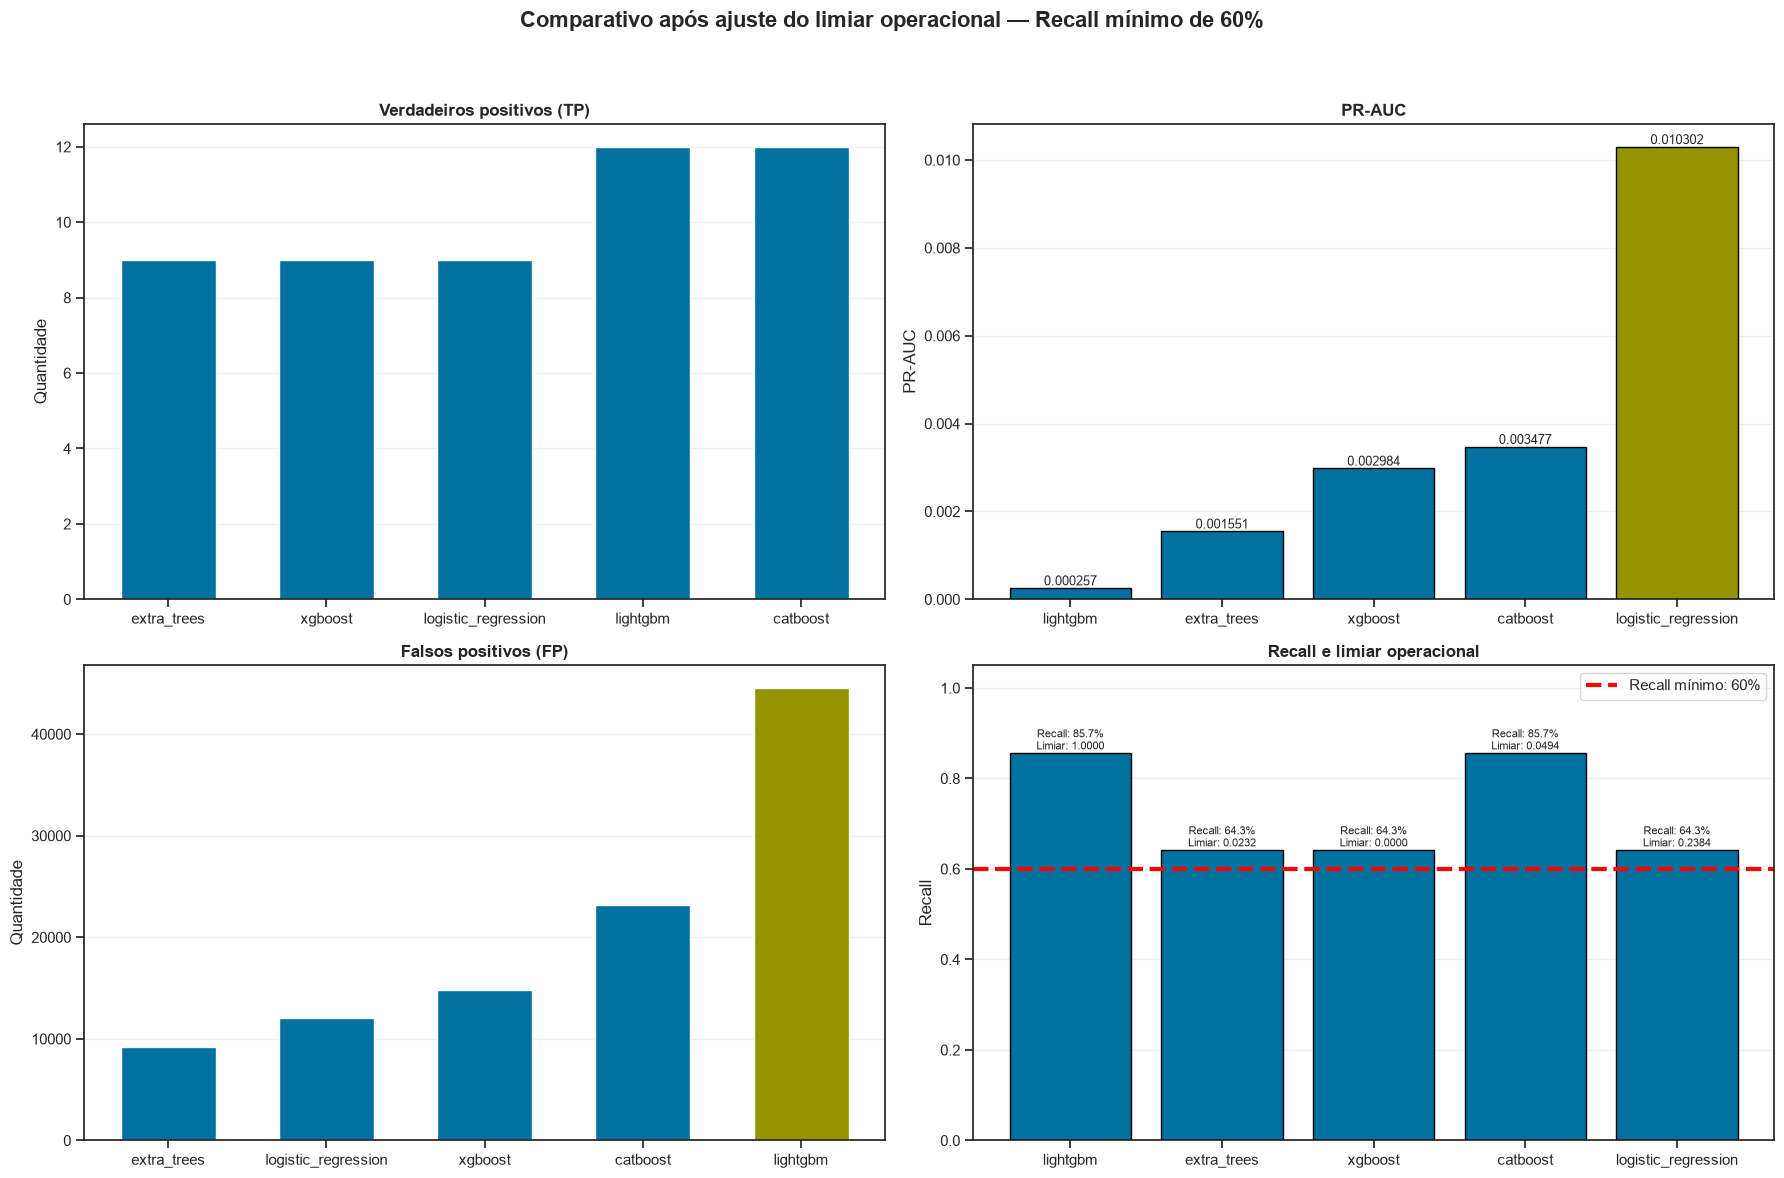


Gráfico salvo com sucesso em: ..\reports\figures\n05_operational_threshold_comparison.png


In [ ]:
# Comparativo dos resultados após o ajuste do limiar operacional

full_image_path = FIGURE_OPERATIONAL_THRESHOLD_COMPARISON
relative_image_path = os.path.relpath(full_image_path)


# Destaca a barra com o valor máximo em uma cor diferente
def highlight_max_bar(values):
    values = np.asarray(values)
    max_value = np.max(values)

    if np.count_nonzero(values == max_value) != 1:
        return [colors[1]] * len(values)

    max_index = int(np.argmax(values))

    return [
        colors[0] if index == max_index else colors[1] for index in range(len(values))
    ]


operational_plot = (
    operational_comparison.copy()
    .sort_values("pr_auc", ascending=True)
    .reset_index(drop=True)
)

tp_plot = operational_plot.sort_values(
    "verdadeiros_positivos (TP)",
    ascending=True,
).reset_index(drop=True)

x_tp = np.arange(len(tp_plot))

fp_plot = operational_plot.sort_values(
    "falsos_positivos (FP)",
    ascending=True,
).reset_index(drop=True)

x_fp = np.arange(len(fp_plot))

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(
    "Comparativo após ajuste do limiar operacional — Recall mínimo de 60%",
    fontsize=16,
    fontweight="bold",
)

models = operational_plot["modelo"]
x = np.arange(len(models))

# 1. Verdadeiros positivos e falsos positivos
axes[0, 0].bar(
    x_tp,
    tp_plot["verdadeiros_positivos (TP)"],
    width=0.6,
    label="Verdadeiros positivos (TP)",
    color=highlight_max_bar(tp_plot["verdadeiros_positivos (TP)"]),
)

axes[0, 0].set_title("Verdadeiros positivos (TP)", fontweight="bold")
axes[0, 0].set_ylabel("Quantidade")
axes[0, 0].set_xticks(x_tp)
axes[0, 0].set_xticklabels(tp_plot["modelo"], rotation=0, ha="center")
axes[0, 0].grid(axis="y", alpha=0.3)

# 2. PR-AUC
bars = axes[0, 1].bar(
    x,
    operational_plot["pr_auc"],
    color=highlight_max_bar(operational_plot["pr_auc"]),
    edgecolor="black",
)

axes[0, 1].set_title("PR-AUC", fontweight="bold")
axes[0, 1].set_ylabel("PR-AUC")
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(models, rotation=0, ha="center")
axes[0, 1].grid(axis="y", alpha=0.3)

for bar, value in zip(bars, operational_plot["pr_auc"]):
    axes[0, 1].annotate(
        f"{value:.6f}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        fontsize=9,
        rotation=0,
    )

# 3. Falsos positivos (FP)
axes[1, 0].bar(
    x_fp,
    fp_plot["falsos_positivos (FP)"],
    width=0.6,
    label="Falsos positivos (FP)",
    color=highlight_max_bar(fp_plot["falsos_positivos (FP)"]),
)

axes[1, 0].set_title("Falsos positivos (FP)", fontweight="bold")
axes[1, 0].set_ylabel("Quantidade")
axes[1, 0].set_xticks(x_fp)
axes[1, 0].set_xticklabels(fp_plot["modelo"], rotation=0, ha="center")
axes[1, 0].grid(axis="y", alpha=0.3)

# 4. Recall e limiar operacional
bars = axes[1, 1].bar(
    x,
    operational_plot["recall"],
    color=highlight_max_bar(operational_plot["recall"]),
    edgecolor="black",
)

axes[1, 1].axhline(
    0.60,
    color="red",
    linestyle="--",
    linewidth=3,
    label="Recall mínimo: 60%",
)

axes[1, 1].set_title("Recall e limiar operacional", fontweight="bold")
axes[1, 1].set_ylabel("Recall")
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(models, rotation=0, ha="center")
axes[1, 1].legend()
axes[1, 1].grid(axis="y", alpha=0.3)

for bar, recall, threshold in zip(
    bars,
    operational_plot["recall"],
    operational_plot["limiar_recall_60"],
):
    axes[1, 1].annotate(
        f"Recall: {recall:.1%}\nLimiar: {threshold:.4f}",
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
        ),
        ha="center",
        va="bottom",
        fontsize=8,
    )

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(full_image_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\nGráfico salvo com sucesso em: {os.path.relpath(relative_image_path)}")

In [38]:
df_cv = tuning_summary.set_index("modelo")
df_op = operational_comparison.set_index("modelo")
col_cv = "melhor_pr_auc_cv"

lr = df_op.loc["logistic_regression"]
xgb = df_op.loc["xgboost"]
et = df_op.loc["extra_trees"]
cb = df_op.loc["catboost"]
lgb = df_op.loc["lightgbm"]

xgb_cv_pr = df_cv.loc["xgboost", col_cv]
total_positivos = int(y_validation.sum())

display(
    Markdown(
        f"* Os estimadores superaram a meta regulatória (Recall $\\geq 60$%) na partição neutra de validação.\n\n "
        f"* Embora o **XGBoost** tenha apresentado o maior "
        f"PR-AUC médio na validação cruzada (`{xgb_cv_pr:.8f}`), sofreu degradação na validação temporal (`PR-AUC = {xgb['pr_auc']:.8f}`), "
        f"demandando um limiar extremamente baixo (`{xgb['limiar_recall_60']:.8f}`).\n\n"
        f"* Em contrapartida, a **Regressão Logística** manteve a ordenação mais estável, entregando o maior **PR-AUC ({lr['pr_auc']:.8f})**,"
        f"o maior **ROC-AUC ({lr['roc_auc']:.8f})** e um ponto de corte equilibrado (`limiar = {lr['limiar_recall_60']:.8f}`).\n\n"
        f"* **Regressão Logística**, **XGBoost** e **Extra Trees** alcançaram **{lr['recall']:.2%} de Recall** "
        f"(capturando **{int(lr['verdadeiros_positivos (TP)'])} dos {total_positivos} casos positivos**), "
        f"enquanto **CatBoost** e **LightGBM** entregaram **{cb['recall']:.2%} de Recall** "
        f"(detectando **{int(cb['verdadeiros_positivos (TP)'])} dos {total_positivos} positivos**).\n\n"
        f"* O **Extra Trees** e a **Regressão Logística** demonstraram a maior eficiência de triagem, "
        f"gerando **{int(et['total_alertas']):,}** e **{int(lr['total_alertas']):,} alertas totais** para garantir os "
        f"**{lr['recall']:.1%}** de cobertura.\n\n "
        f"* No extremo oposto, o **LightGBM** gerou um volume operacional impraticável de **{int(lgb['total_alertas']):,} alertas** "
        f"para capturar **{total_positivos}** ocorrências (Precisão de apenas **{lgb['precision']:.4%}**)."
    )
)

* Os estimadores superaram a meta regulatória (Recall $\geq 60$%) na partição neutra de validação.

 * Embora o **XGBoost** tenha apresentado o maior PR-AUC médio na validação cruzada (`0.03072865`), sofreu degradação na validação temporal (`PR-AUC = 0.00298361`), demandando um limiar extremamente baixo (`0.00004805`).

* Em contrapartida, a **Regressão Logística** manteve a ordenação mais estável, entregando o maior **PR-AUC (0.01030154)**,o maior **ROC-AUC (0.86806869)** e um ponto de corte equilibrado (`limiar = 0.23843337`).

* **Regressão Logística**, **XGBoost** e **Extra Trees** alcançaram **64.29% de Recall** (capturando **9 dos 14 casos positivos**), enquanto **CatBoost** e **LightGBM** entregaram **85.71% de Recall** (detectando **12 dos 14 positivos**).

* O **Extra Trees** e a **Regressão Logística** demonstraram a maior eficiência de triagem, gerando **9,187** e **12,015 alertas totais** para garantir os **64.3%** de cobertura.

 * No extremo oposto, o **LightGBM** gerou um volume operacional impraticável de **44,556 alertas** para capturar **14** ocorrências (Precisão de apenas **0.0269%**).

### 10.2. Avaliação final no teste

O campeão é selecionado pelo maior PR-AUC observado na validação. Após a seleção, o limiar operacional é ajustado exclusivamente para atingir o Recall mínimo definido. Precision, Recall e volume de alertas são apresentados como indicadores operacionais complementares.

In [26]:
# Seleção do campeão com base em PR-AUC e cumprimento do Recall mínimo

champion_rank = (
    operational_comparison[operational_comparison["recall"] >= RECALL_FLOOR]
    .sort_values(
        ["pr_auc", "precision", "total_alertas"],
        ascending=[False, False, True],
    )
    .reset_index(drop=True)
)

if champion_rank.empty:
    raise ValueError(f"Nenhum modelo atingiu o Recall mínimo de {RECALL_FLOOR:.0%}.")

champion_name = champion_rank.loc[0, "modelo"]
champion_threshold = limiar_thresholds[champion_name]

champion_selection = {
    "modelo_selecionado": champion_name,
    "criterio_selecao": (
        "Maior PR-AUC entre os modelos que atingiram o Recall mínimo; "
        "desempate por Precisão e menor volume de alertas"
    ),
    "recall_floor": float(RECALL_FLOOR),
    "limiar_validacao": float(champion_threshold),
    "limiar_operacional": float(champion_threshold),
    "ranking_validacao": champion_rank[
        [
            "modelo",
            "precision",
            "recall",
            "f1_score",
            "roc_auc",
            "pr_auc",
            "limiar_recall_60",
            "total_alertas",
        ]
    ].to_dict(orient="records"),
}
display(Markdown(f"**Campeão selecionado na validação:** {champion_name}"))
display(
    Markdown(
        f"**Critério:** maior PR-AUC entre modelos com Recall "
        f"mínimo de {RECALL_FLOOR:.0%}"
    )
)
display(Markdown(f"**Limiar de validação:** {champion_threshold:.8f}"))

**Campeão selecionado na validação:** logistic_regression

**Critério:** maior PR-AUC entre modelos com Recall mínimo de 60%

**Limiar de validação:** 0.23843337

In [53]:
# Avaliação final no conjunto de teste com o limiar da validação
model_final = tuned_models[champion_name]
X_test_arr = X_test
y_test_arr = np.asarray(y_test.squeeze() if hasattr(y_test, "squeeze") else y_test)

test_scores = model_final.predict_proba(X_test_arr)[:, 1]
test_predictions = (test_scores >= champion_threshold).astype(int)

test_metrics = evaluate_classifier(
    champion_name,
    y_test_arr,
    test_predictions,
    test_scores,
)

test_confusion = confusion_matrix(y_test_arr, test_predictions)

tn, fp, fn, tp = test_confusion.ravel()

test_metrics.update(
    {
        "limiar_operacional": float(champion_threshold),
        "total_alertas": int(test_predictions.sum()),
        "TP": int(tp),
        "FP": int(fp),
        "TN": int(tn),
        "FN": int(fn),
    }
)

display(Markdown(f"**Modelo avaliado no teste:** {champion_name}"))
display(Markdown(f"**Limiar utilizado no teste:** {champion_threshold:.8f}"))
display(pd.DataFrame([test_metrics]))
display(
    pd.DataFrame(
        test_confusion,
        index=["real_0", "real_1"],
        columns=["predito_0", "predito_1"],
    )
)

**Modelo avaliado no teste:** logistic_regression

**Limiar utilizado no teste:** 0.23843337

,modelo,precision,recall,f1_score,roc_auc,pr_auc,limiar_operacional,total_alertas,TP,FP,TN,FN
0,logistic_regression,0.00034973,0.50000000,0.00069897,0.87539602,0.00062382,0.23843337,8578,3,8575,60445,3


,predito_0,predito_1
real_0,60445,8575
real_1,3,3


### 10.3. Persistência do modelo campeão

In [64]:
# Persistência dos resultados finais e metadados

baseline_metrics_row = (
    baseline_metrics.iloc[0]
    if isinstance(baseline_metrics, pd.DataFrame)
    else baseline_metrics
)

baseline_metrics_payload = {
    "modelo": str(baseline_metrics_row["modelo"]),
    "precision": float(baseline_metrics_row["precision"]),
    "recall": float(baseline_metrics_row["recall"]),
    "f1_score": float(baseline_metrics_row["f1_score"]),
    "roc_auc": float(baseline_metrics_row["roc_auc"]),
    "pr_auc": float(baseline_metrics_row["pr_auc"]),
}

# Persistência do resultado final do teste
final_selection = {
    "modelo": model_final,
    "modelo_selecionado": champion_name,
    "limiar_validacao": float(champion_threshold),
    "limiar_operacional": float(champion_threshold),
    "avaliacao_operacional_validacao": operational_comparison[
        operational_comparison["modelo"] == champion_name
    ]
    .iloc[0]
    .to_dict(),
    "features_list": list(X_train.columns),
    "random_state": int(RANDOM_STATE),
    "scale_pos_weight": float(scale_pos_weight),
    "avaliacao_teste": {
        "precision": float(test_metrics["precision"]),
        "recall": float(test_metrics["recall"]),
        "f1_score": float(test_metrics["f1_score"]),
        "roc_auc": float(test_metrics["roc_auc"]),
        "pr_auc": float(test_metrics["pr_auc"]),
    },
    "matriz_confusao": test_confusion.tolist(),
    "baseline_metrics": baseline_metrics_payload,
}

# Persistência dos metadados
metadata_payload = {
    "modelo": champion_name,
    "modelo_selecionado": champion_name,
    "limiar_validacao": float(champion_threshold),
    "limiar_operacional": float(champion_threshold),
    "operational_comparison": operational_comparison.to_dict(
        orient="records"
    ),
    "features_list": list(X_train.columns),
    "random_state": int(RANDOM_STATE),
    "scale_pos_weight": float(scale_pos_weight),
    "baseline_metrics": baseline_metrics_payload,
}

# Persistência dos arquivos (.joblib)
joblib.dump(final_selection, MODEL_PATH)
joblib.dump(metadata_payload, MODEL_METADATA_PATH)

# Persistência dos metadados em JSON
metadata_json_payload = dict(final_selection)
metadata_json_payload["modelo"] = champion_name

with open(MODEL_METADATA_JSON, "w", encoding="utf-8") as file:
    json.dump(
        metadata_json_payload,
        file,
        ensure_ascii=False,
        indent=2,
        default=str,
    )

relative_path = os.path.relpath(MODEL_DIR)

print(
    f"\nAvaliação final, estimador treinado e metadados persistidos com sucesso em: {relative_path}"
)


Avaliação final, estimador treinado e metadados persistidos com sucesso em: ..\models


In [ ]:
# Tabela final de métricas do teste com limiar da validação
full_table_path = TABLE_CHAMPION_METRICS
relative_table_path = os.path.relpath(full_table_path)

df_final_test = pd.DataFrame([test_metrics])

ordered_columns = [
    "modelo",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "limiar_operacional",
    "total_alertas",
    "TP",
    "FP",
    "TN",
    "FN",
]

existent_columns = [col for col in ordered_columns if col in df_final_test.columns]
df_final_test = df_final_test[existent_columns]

df_final_test.to_csv(full_table_path, index=False)

print(f"\nTabela final de teste salva com sucesso em: {relative_table_path}")
display(df_final_test)


Tabela final de teste salva com sucesso em: ..\docs\metadata\n05_champion_metrics.csv


,modelo,precision,recall,f1_score,roc_auc,pr_auc,limiar_operacional,total_alertas,TP,FP,TN,FN
0,logistic_regression,0.00034973,0.50000000,0.00069897,0.87539602,0.00062382,0.23843337,8578,3,8575,60445,3


### 10.4. Matriz de confusão campeão

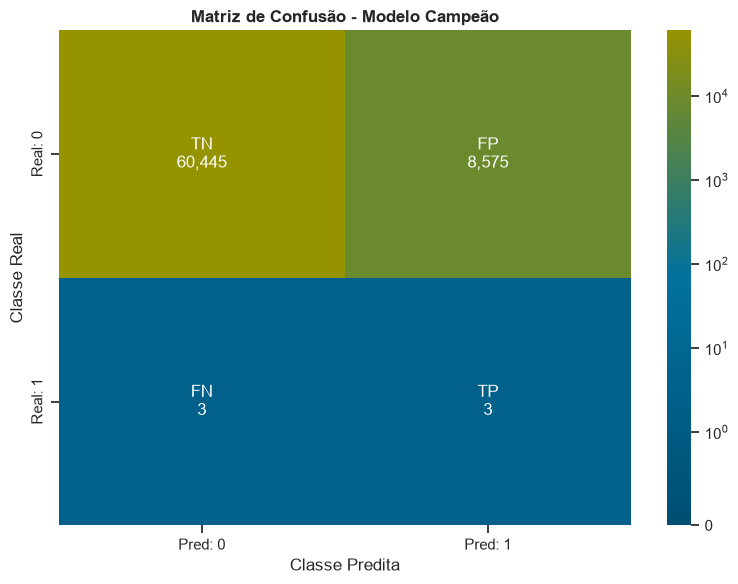


Gráfico salvo com sucesso em: ..\reports\figures\n05_final_confusion_matrix.png


In [ ]:
# Matriz de confusão do modelo campeão

full_image_path = FIGURE_CHAMPION_CONFUSION_MATRIX
relative_image_path = os.path.relpath(full_image_path)

tn, fp, fn, tp = test_confusion.ravel()

labels = [
    [f"TN\n{tn:,}", f"FP\n{fp:,}"],
    [f"FN\n{fn:,}", f"TP\n{tp:,}"],
]

plt.figure(figsize=(8, 6))
sns.heatmap(
    test_confusion,
    annot=labels,
    fmt="",
    cmap=custom_cmap,
    norm=SymLogNorm(
        linthresh=1.0,
        vmin=0,
        vmax=test_confusion.max(),
        base=10,
    ),
    cbar=True,
    xticklabels=["Pred: 0", "Pred: 1"],
    yticklabels=["Real: 0", "Real: 1"],
)
plt.ylabel("Classe Real")
plt.xlabel("Classe Predita")
plt.title("Matriz de Confusão - Modelo Campeão", fontweight="bold")

plt.tight_layout()
plt.savefig(relative_image_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"\nGráfico salvo com sucesso em: {relative_image_path}")

In [63]:
total_positivos_teste = tp + fn
total_alertas_teste = tp + fp
taxa_falsos_alertas = fp / total_alertas_teste if total_alertas_teste else 0
taxa_transgressoes_nao_detectadas = (
    fn / total_positivos_teste if total_positivos_teste else 0
)

display(Markdown(f"""
- No teste de 2025, o modelo **{champion_name}** classificou corretamente
  **{tn:,} observações negativas** e identificou **{tp:,} das
  {total_positivos_teste:,} transgressões reais**.

- O modelo deixou de identificar **{fn:,} transgressões**, resultando em Recall
  de **{test_metrics["recall"]:.2%}**. Também gerou **{fp:,} falsos positivos**
  entre **{total_alertas_teste:,} alertas** emitidos.

- A Precisão foi de **{test_metrics["precision"]:.2%}**, indicando que
  **{taxa_falsos_alertas:.2%} dos alertas foram falsos positivos**.

- Portanto, no teste, o limiar **{champion_threshold:.8f}** priorizou a cobertura
  de transgressões, mas ainda produziu um volume relevante de alertas incorretos.
  A adoção operacional deve considerar se esse custo de triagem é aceitável.
"""))


- No teste de 2025, o modelo **logistic_regression** classificou corretamente
  **60,445 observações negativas** e identificou **3 das
  6 transgressões reais**.

- O modelo deixou de identificar **3 transgressões**, resultando em Recall
  de **50.00%**. Também gerou **8,575 falsos positivos**
  entre **8,578 alertas** emitidos.

- A Precisão foi de **0.03%**, indicando que
  **99.97% dos alertas foram falsos positivos**.

- Portanto, no teste, o limiar **0.23843337** priorizou a cobertura
  de transgressões, mas ainda produziu um volume relevante de alertas incorretos.
  A adoção operacional deve considerar se esse custo de triagem é aceitável.


---

## 11. Conclusão

* O desbalanceamento da base justificou o uso de métricas como **PR-AUC**, **Recall**, **Precision** e **matriz de confusão**, evitando que a acurácia mascarasse a baixa capacidade de detecção da classe positiva.

* A seleção do modelo foi baseada no maior PR-AUC observado na validação. Posteriormente, o limiar operacional foi ajustado exclusivamente na validação para atender ao Recall mínimo definido, mantendo o conjunto de teste reservado para a avaliação final.

* Os resultados evidenciam um trade-off entre cobertura e esforço operacional: aumentar o Recall tende a elevar o volume de falsos positivos e, consequentemente, a quantidade de alertas que precisam ser analisados.